In [23]:
import pandas as pd
import matplotlib.pyplot as plt

EDA:
-Cargar y explorar el dataset
-Limpiar y preparar los datos
-Analizar y visualizar los datos
-Extraer conclusiones

In [24]:
#Cargar dataset
titanic = pd.read_csv("titanic_tutoria_3.csv")

In [25]:
titanic

,nombre,sobrevivio,clase,sexo,edad,tarifa,embarcacion,cabina
0,Jack Dawson,0,3,male,20.0,7.25,S,NaN
1,Rose DeWitt,1,1,female,17.0,512.33,C,B57
2,John Smith,0,2,male,35.0,13.00,S,NaN
3,Mary Johnson,1,1,female,28.0,76.29,C,C85
4,Thomas Brown,0,3,male,NaN,8.05,S,NaN
5,Elisabeth Jones,1,1,female,45.0,35.50,S,C103
6,William Davis,0,3,male,23.0,7.92,Q,NaN
7,Sarah Wilson,1,2,female,31.0,21.00,S,NaN
8,James Miller,0,3,male,NaN,7.75,Q,NaN
9,Emma Moore,1,1,female,22.0,151.55,S,B45


In [26]:
#Exploración inicial
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nombre       31 non-null     object 
 1   sobrevivio   31 non-null     int64  
 2   clase        31 non-null     int64  
 3   sexo         31 non-null     object 
 4   edad         27 non-null     float64
 5   tarifa       31 non-null     float64
 6   embarcacion  31 non-null     object 
 7   cabina       11 non-null     object 
dtypes: float64(2), int64(2), object(4)
memory usage: 2.1+ KB


In [27]:
# Variable numericas con descripciones estadisticas básicas
titanic.describe()

,sobrevivio,clase,edad,tarifa
count,31.000000,31.000000,27.000000,31.000000
mean,0.516129,2.129032,33.222222,52.375161
std,0.508001,0.921663,11.056962,98.678691
min,0.000000,1.000000,17.000000,7.250000
25%,0.000000,1.000000,25.000000,7.920000
50%,1.000000,2.000000,33.000000,13.000000
75%,1.000000,3.000000,39.000000,55.700000
max,1.000000,3.000000,62.000000,512.330000


In [28]:
#Contar nulos en total por columna
titanic.isnull().sum()

nombre          0
sobrevivio      0
clase           0
sexo            0
edad            4
tarifa          0
embarcacion     0
cabina         20
dtype: int64

In [29]:
titanic_nuevo = titanic.drop(columns=["cabina"])
titanic_nuevo = titanic_nuevo.drop_duplicates()

In [30]:
#¿Qué hacer con edad?
mediana_edad = titanic_nuevo["edad"].median()
print(f"Mediana de edad: {mediana_edad}")

Mediana de edad: 32.0


In [31]:
#Rellenar los valores nulos de 'edad' con la mediana
titanic_nuevo["edad"] = titanic_nuevo["edad"].fillna(mediana_edad)

print(f"Filas y columnas después de limpiar: {titanic_nuevo.shape}")
titanic_nuevo.info()


Filas y columnas después de limpiar: (30, 7)
<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nombre       30 non-null     object 
 1   sobrevivio   30 non-null     int64  
 2   clase        30 non-null     int64  
 3   sexo         30 non-null     object 
 4   edad         30 non-null     float64
 5   tarifa       30 non-null     float64
 6   embarcacion  30 non-null     object 
dtypes: float64(2), int64(2), object(3)
memory usage: 1.9+ KB


In [32]:
titanic_nuevo["edad"]

0     20.0
1     17.0
2     35.0
3     28.0
4     32.0
5     45.0
6     23.0
7     31.0
8     32.0
9     22.0
10    42.0
11    26.0
12    19.0
13    55.0
14    29.0
15    38.0
16    32.0
17    33.0
18    40.0
19    24.0
20    36.0
21    29.0
22    47.0
23    21.0
24    33.0
25    62.0
26    32.0
27    27.0
28    44.0
29    36.0
Name: edad, dtype: float64

In [33]:
#Crear grupo de edades para otro analisis

titanic_nuevo["edad_grupo"] = pd.cut(
    titanic_nuevo["edad"],
    bins=[0,25,40,100],
    labels=["joven", "adulto", "mayor"]
)

titanic_nuevo[["edad", "edad_grupo"]].head(30)

,edad,edad_grupo
0,20.0,joven
1,17.0,joven
2,35.0,adulto
3,28.0,adulto
4,32.0,adulto
5,45.0,mayor
6,23.0,joven
7,31.0,adulto
8,32.0,adulto
9,22.0,joven


In [34]:
#Cambiar tipo de datos de edad de float a int
titanic_nuevo["edad"] = titanic_nuevo["edad"].astype(int)

In [35]:
titanic_nuevo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   nombre       30 non-null     object  
 1   sobrevivio   30 non-null     int64   
 2   clase        30 non-null     int64   
 3   sexo         30 non-null     object  
 4   edad         30 non-null     int64   
 5   tarifa       30 non-null     float64 
 6   embarcacion  30 non-null     object  
 7   edad_grupo   30 non-null     category
dtypes: category(1), float64(1), int64(3), object(3)
memory usage: 2.0+ KB


In [36]:
titanic_nuevo["edad"]

0     20
1     17
2     35
3     28
4     32
5     45
6     23
7     31
8     32
9     22
10    42
11    26
12    19
13    55
14    29
15    38
16    32
17    33
18    40
19    24
20    36
21    29
22    47
23    21
24    33
25    62
26    32
27    27
28    44
29    36
Name: edad, dtype: int64

Visualizaciones

In [37]:
supervivencia_sexo = titanic_nuevo.groupby("sexo")["sobrevivio"].mean()

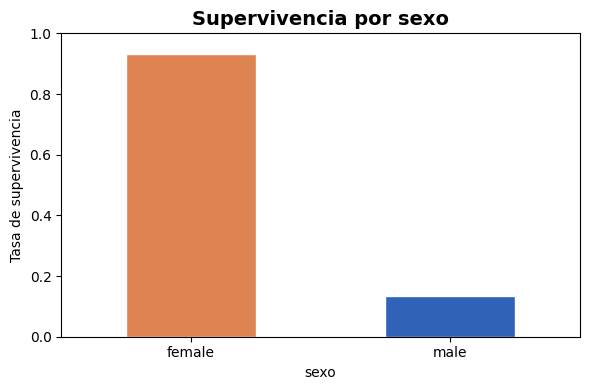

In [41]:
plt.figure(figsize=(6, 4))
supervivencia_sexo.plot(kind="bar", color=["#DD8452", "#3062B8"], edgecolor = "white", width=0.5)
plt.title("Supervivencia por sexo", fontsize=14, fontweight="bold")
plt.xlabel("sexo")
plt.ylabel("Tasa de supervivencia")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.tight_layout()
plt.show()


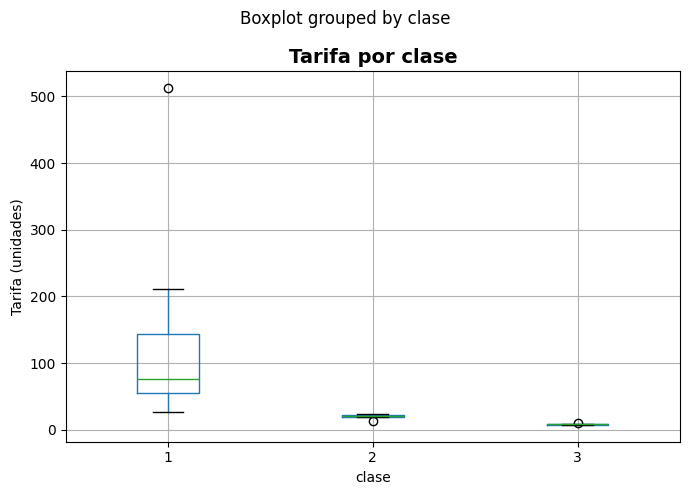

In [43]:
#Boxplot
titanic_nuevo.boxplot(column="tarifa", by="clase", figsize=(7,5))
plt.title("Tarifa por clase", fontsize=14, fontweight="bold")
plt.xlabel("clase")
plt.ylabel("Tarifa (unidades)")
plt.tight_layout()
plt.show()

In [44]:
titanic_nuevo["tarifa"]

0       7.25
1     512.33
2      13.00
3      76.29
4       8.05
5      35.50
6       7.92
7      21.00
8       7.75
9     151.55
10     52.00
11      7.92
12      8.05
13     59.40
14      7.25
15     23.00
16      7.55
17     83.15
18      9.50
19      7.75
20      7.25
21    211.34
22     71.00
23      8.43
24      7.92
25     26.55
26      7.25
27     21.00
28      8.05
29    135.63
Name: tarifa, dtype: float64